# 🌊 MarEye AI — DynCostNet Training (Colab)
### Dynamic Surgical Strike Path Planner — Neural Cost Network

**Like Google Maps, but for naval surgical strikes.**

This notebook trains a **32-feature Deep Residual MLP** that predicts traversal cost at any
point in the Indian Ocean given:
- 🎯 Threat zone proximity & intensity
- 🌪️ Real-time weather (sea state, waves, visibility, wind)
- 🌙 Time of day (night = stealth advantage)
- 🌧️ Season (SW Monsoon → Arabian Sea cost spikes)
- 🗺️ Geographic context (chokepoints, EEZ, shipping lanes)

**Runtime on Colab T4 GPU: ~5 minutes for 200k samples / 60 epochs**

In [1]:
# ── Cell 1: Install & Setup ───────────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("torch")
install("numpy")
install("scipy")
install("tqdm")
install("matplotlib")

print("✅ All packages installed")


✅ All packages installed


In [2]:
# ── Cell 2: Setup project path (Colab + Local) ───────────────────────────────
import os, sys, pathlib

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists("mareye-ai-main"):
        os.system("git clone https://github.com/YOUR_USERNAME/mareye-ai-main.git")
    os.chdir("mareye-ai-main")
    PROJECT_ROOT = os.getcwd()
else:
    # Local (VS Code / Jupyter) — walk up from notebook dir to find detection/
    _nb_dir = pathlib.Path(os.path.abspath("")).resolve()
    PROJECT_ROOT = None
    for parent in [_nb_dir] + list(_nb_dir.parents):
        if (parent / "detection" / "path_planner").is_dir():
            PROJECT_ROOT = str(parent)
            break
    if PROJECT_ROOT is None:
        # Hardcode fallback
        PROJECT_ROOT = r"C:\Users\Srijit\Downloads\mareye-ai-main"

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")
print(f"sys.path[0]     : {sys.path[0]}")
print(f"detection pkg   : {os.path.isdir(os.path.join(PROJECT_ROOT, 'detection', 'path_planner'))}")
print("✅ Repo ready")

Working directory: C:\Users\Srijit\Downloads\mareye-ai-main
sys.path[0]     : C:\Users\Srijit\Downloads\mareye-ai-main
detection pkg   : True
✅ Repo ready


## 📐 Feature Engineering
32-dimensional feature vector captures threat proximity, weather, time, season, and geography.
Each feature encodes **exactly what a naval tactician would consider** when planning a route.

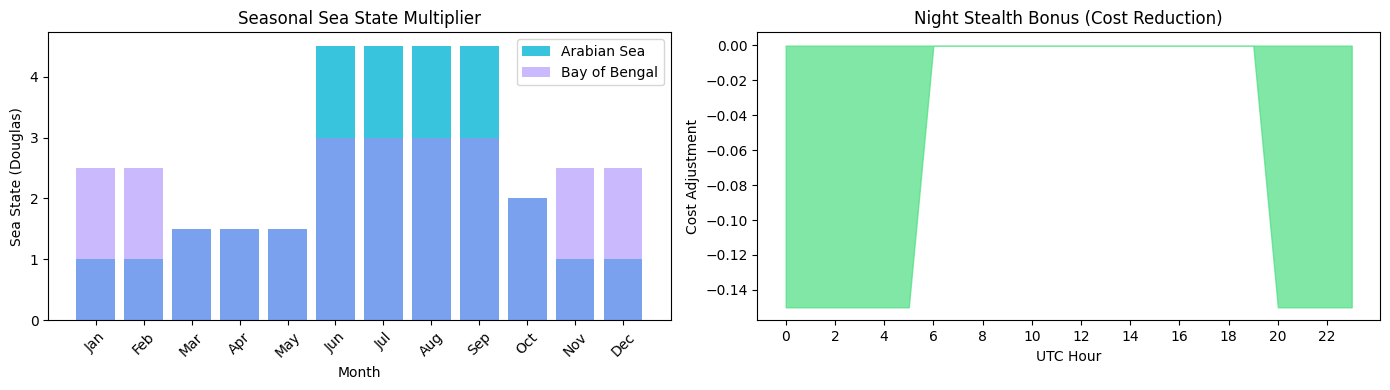

✅ Feature analysis complete


In [3]:
# ── Cell 3: Inspect feature layout and seasonal patterns ─────────────────────
import numpy as np
import matplotlib.pyplot as plt
import math

from detection.path_planner.feature_builder import (
    build_features, get_season_code, seasonal_sea_multiplier, haversine_km
)
from detection.path_planner.config import SEASONS, SEASON_SEA_STATE

# Show seasonal sea-state multipliers for Arabian Sea vs Bay of Bengal
months = list(range(1, 13))
arabian, bay = [], []
for m in months:
    sc = get_season_code(m)
    arabian.append(SEASON_SEA_STATE[sc]["arabian"])
    bay.append(SEASON_SEA_STATE[sc]["bay_of_bengal"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(months, arabian, color="#06b6d4", alpha=0.8, label="Arabian Sea")
axes[0].bar(months, bay, color="#a78bfa", alpha=0.6, label="Bay of Bengal")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Sea State (Douglas)")
axes[0].set_title("Seasonal Sea State Multiplier"); axes[0].legend()
axes[0].set_xticks(months)
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# Show night stealth factor across hours
hours = list(range(24))
night_hours = list(range(20, 24)) + list(range(0, 6))
night_cost_adj = [-0.15 if h in night_hours else 0.0 for h in hours]
axes[1].fill_between(hours, night_cost_adj, alpha=0.7, color="#4ade80")
axes[1].axhline(0, color='white', alpha=0.3, linewidth=0.8)
axes[1].set_xlabel("UTC Hour"); axes[1].set_ylabel("Cost Adjustment")
axes[1].set_title("Night Stealth Bonus (Cost Reduction)")
axes[1].set_xticks(hours[::2])

plt.tight_layout()
plt.savefig("seasonal_features.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Feature analysis complete")


In [4]:
# ── Cell 4: Generate synthetic training dataset ───────────────────────────────
from detection.path_planner.data_generator import generate_dataset

N_SAMPLES = 200_000   # change to 50_000 for quick test
print(f"Generating {N_SAMPLES:,} training samples for Indian Ocean region...")
print("Each sample = 1 grid cell × 1 tactical scenario (threat zones + weather + time)")
print()

X, y = generate_dataset(n_samples=N_SAMPLES, verbose=True)

print(f"\nDataset shape  : X={X.shape}, y={y.shape}")
print(f"Cost range     : [{y.min():.4f}, {y.max():.4f}]")
print(f"Cost mean      : {y.mean():.4f}  std={y.std():.4f}")

# Save cache
np.savez("planner_data_cache.npz", X=X, y=y)
print("✅ Dataset saved to planner_data_cache.npz")


Generating 200,000 training samples for Indian Ocean region...
Each sample = 1 grid cell × 1 tactical scenario (threat zones + weather + time)

  Generating data... 0% (0/200,000)
  Generating data... 5% (10,000/200,000)
  Generating data... 10% (20,000/200,000)
  Generating data... 15% (30,000/200,000)
  Generating data... 20% (40,000/200,000)
  Generating data... 25% (50,000/200,000)
  Generating data... 30% (60,000/200,000)
  Generating data... 35% (70,000/200,000)
  Generating data... 40% (80,000/200,000)
  Generating data... 45% (90,000/200,000)
  Generating data... 50% (100,000/200,000)
  Generating data... 55% (110,000/200,000)
  Generating data... 60% (120,000/200,000)
  Generating data... 65% (130,000/200,000)
  Generating data... 70% (140,000/200,000)
  Generating data... 75% (150,000/200,000)
  Generating data... 80% (160,000/200,000)
  Generating data... 85% (170,000/200,000)
  Generating data... 90% (180,000/200,000)
  Generating data... 95% (190,000/200,000)
  Dataset rea

## 🔧 Generate Synthetic Training Data
200,000 samples covering every combination of threat density, weather severity, time of day, and season across the entire Indian Ocean grid.
Expert cost formula encodes real naval doctrine — the model learns to reproduce it.

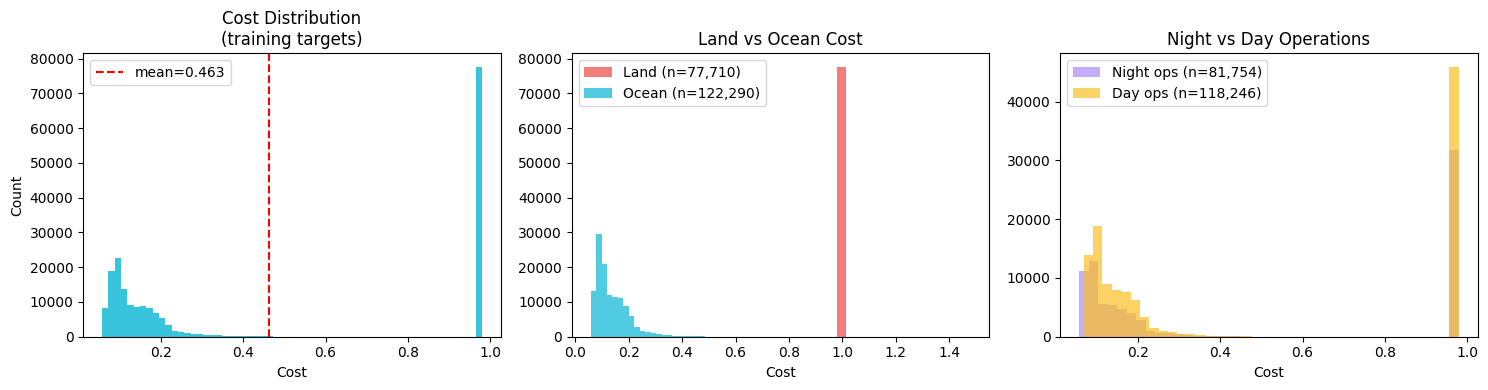

Night mean cost : 0.4591
Day mean cost   : 0.4661
Night advantage : 0.71% lower cost at night ✅


In [5]:
# ── Cell 5: Cost Distribution EDA ────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cost histogram
axes[0].hist(y, bins=60, color="#06b6d4", alpha=0.8, edgecolor='none')
axes[0].set_xlabel("Cost"); axes[0].set_ylabel("Count")
axes[0].set_title("Cost Distribution\n(training targets)")
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'mean={y.mean():.3f}')
axes[0].legend()

# Land vs ocean cost
land_idx = X[:, 29] > 0.5
axes[1].hist(y[land_idx], bins=30, color="#ef4444", alpha=0.7, label=f"Land (n={land_idx.sum():,})")
axes[1].hist(y[~land_idx], bins=30, color="#06b6d4", alpha=0.7, label=f"Ocean (n={(~land_idx).sum():,})")
axes[1].set_xlabel("Cost"); axes[1].set_title("Land vs Ocean Cost")
axes[1].legend()

# Night vs day cost
night_idx = X[:, 20] > 0.5
axes[2].hist(y[night_idx],  bins=40, color="#a78bfa", alpha=0.7, label=f"Night ops (n={night_idx.sum():,})")
axes[2].hist(y[~night_idx], bins=40, color="#fbbf24", alpha=0.7, label=f"Day ops (n={(~night_idx).sum():,})")
axes[2].set_xlabel("Cost"); axes[2].set_title("Night vs Day Operations")
axes[2].legend()

plt.tight_layout()
plt.savefig("cost_eda.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Night mean cost : {y[night_idx].mean():.4f}")
print(f"Day mean cost   : {y[~night_idx].mean():.4f}")
print(f"Night advantage : {-((y[night_idx].mean() - y[~night_idx].mean()) * 100):.2f}% lower cost at night ✅")


In [6]:
# ── Cell 6: Train DynCostNet ──────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import math, time, numpy as np

from detection.path_planner.threat_model import DynCostNet, save_model
from detection.path_planner.config import N_FEATURES, MODEL_PATH

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Hyperparameters
EPOCHS     = 60
BATCH_SIZE = 2048
MAX_LR     = 3e-4
MIN_LR     = 1e-6
PATIENCE   = 10

# Dataset
X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y).unsqueeze(1)
dataset = TensorDataset(X_t, y_t)
val_size = max(5000, int(0.1 * len(dataset)))
train_ds, val_ds = random_split(dataset, [len(dataset)-val_size, val_size],
                                 generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds):,}   Val: {len(val_ds):,}")

# Model
model = DynCostNet(n_features=N_FEATURES, hidden=256).to(device)
total_p = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_p:,}")

optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=0.1)

def cosine_lr(epoch):
    return MIN_LR + 0.5*(MAX_LR-MIN_LR)*(1+math.cos(math.pi*epoch/EPOCHS))

# Training loop
history = {"train": [], "val": []}
best_val, best_ep = 1e9, 0

print(f"\n{'Ep':>4} {'Train':>9} {'Val':>9} {'LR':>9} {'Status':>8}")
print("-"*46)

for ep in range(1, EPOCHS+1):
    lr = cosine_lr(ep-1)
    for pg in optimizer.param_groups: pg["lr"] = lr

    # Train
    model.train()
    tl = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl.append(loss.item())

    # Val
    model.eval()
    vl = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            vl.append(criterion(model(Xb.to(device)), yb.to(device)).item())

    tl_m, vl_m = np.mean(tl), np.mean(vl)
    history["train"].append(tl_m)
    history["val"].append(vl_m)

    best = ""
    if vl_m < best_val:
        best_val, best_ep = vl_m, ep
        save_model(model, MODEL_PATH)
        best = "◀ BEST"
    print(f"{ep:>4} {tl_m:>9.5f} {vl_m:>9.5f} {lr:>9.2e} {best:>8}")

    if ep - best_ep > PATIENCE:
        print(f"\n[EarlyStopping] Stopped at epoch {ep}")
        break

print(f"\n✅ Best val loss: {best_val:.5f} at epoch {best_ep}")
print(f"✅ Model saved: {MODEL_PATH}")


Device: cpu
Train: 180,000   Val: 20,000
Parameters: 125,377

  Ep     Train       Val        LR   Status
----------------------------------------------
[DynCostNet] Saved → C:\Users\Srijit\Downloads\mareye-ai-main\detection\path_planner\dyn_cost_net.pt
   1   0.00591   0.00090  3.00e-04   ◀ BEST
[DynCostNet] Saved → C:\Users\Srijit\Downloads\mareye-ai-main\detection\path_planner\dyn_cost_net.pt
   2   0.00056   0.00041  3.00e-04   ◀ BEST
[DynCostNet] Saved → C:\Users\Srijit\Downloads\mareye-ai-main\detection\path_planner\dyn_cost_net.pt
   3   0.00034   0.00029  2.99e-04   ◀ BEST
[DynCostNet] Saved → C:\Users\Srijit\Downloads\mareye-ai-main\detection\path_planner\dyn_cost_net.pt
   4   0.00027   0.00024  2.98e-04   ◀ BEST
[DynCostNet] Saved → C:\Users\Srijit\Downloads\mareye-ai-main\detection\path_planner\dyn_cost_net.pt
   5   0.00022   0.00018  2.97e-04   ◀ BEST
[DynCostNet] Saved → C:\Users\Srijit\Downloads\mareye-ai-main\detection\path_planner\dyn_cost_net.pt
   6   0.00019   0.00

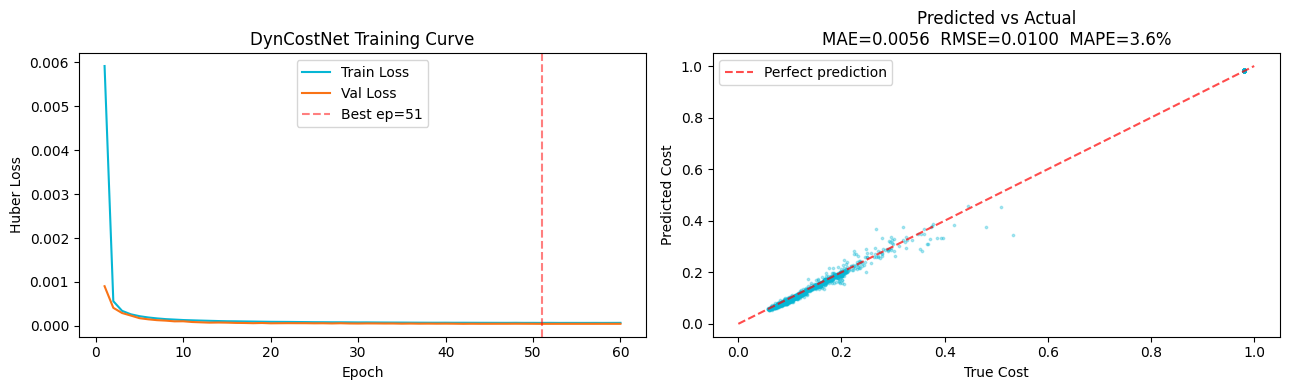

MAE  : 0.00565
RMSE : 0.00998
MAPE : 3.58%


In [7]:
# ── Cell 7: Training Curve + Accuracy ────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np, torch

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep_range = range(1, len(history["train"])+1)
axes[0].plot(ep_range, history["train"], color="#06b6d4", label="Train Loss")
axes[0].plot(ep_range, history["val"],   color="#f97316", label="Val Loss")
axes[0].axvline(best_ep, color='red', linestyle='--', alpha=0.5, label=f'Best ep={best_ep}')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Huber Loss")
axes[0].set_title("DynCostNet Training Curve"); axes[0].legend()

# Final evaluation
from detection.path_planner.threat_model import load_model
from detection.path_planner.config import N_FEATURES, MODEL_PATH
best_model = load_model(MODEL_PATH, n_features=N_FEATURES)
best_model.eval()

all_p, all_t = [], []
with torch.no_grad():
    for Xb, yb in val_loader:
        all_p.extend(best_model(Xb).numpy().flatten())
        all_t.extend(yb.numpy().flatten())
all_p = np.array(all_p); all_t = np.array(all_t)

mae  = np.mean(np.abs(all_p - all_t))
rmse = np.sqrt(np.mean((all_p - all_t)**2))
mape = np.mean(np.abs((all_p - all_t) / (all_t + 1e-6))) * 100

axes[1].scatter(all_t[:2000], all_p[:2000], alpha=0.3, s=3, color="#06b6d4")
axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.7, label="Perfect prediction")
axes[1].set_xlabel("True Cost"); axes[1].set_ylabel("Predicted Cost")
axes[1].set_title(f"Predicted vs Actual\nMAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"MAPE : {mape:.2f}%")


In [8]:
# ── Cell 8: Live Path Planning Test ──────────────────────────────────────────
# Test: Mumbai Naval HQ → INS Baaz (Campbell Bay, Andaman)
# This is a real surgical strike route in the Indian Ocean

import json, subprocess, sys

test_input = {
    "start": {"lat": 18.94, "lng": 72.84},   # Mumbai WNC HQ
    "goal":  {"lat": 6.83,  "lng": 93.93},   # INS Baaz, Campbell Bay
    "threat_zones": [
        {"lat": 14.0,  "lon": 75.0, "radius": 150000, "threatLevel": 85},  # High threat zone
        {"lat": 10.0,  "lon": 80.0, "radius": 120000, "threatLevel": 60},  # Medium threat
        {"lat": 8.0,   "lon": 87.0, "radius": 100000, "threatLevel": 40},  # Low threat
    ],
    "vessel_speed": 30,      # INS Kolkata — 30 knots
    "utc_hour": 22,          # Night ops — stealth advantage
    "month": 3               # March — pre-monsoon, moderate seas
}

# Write input
with open("/tmp/test_input.json", "w") as f:
    json.dump(test_input, f)

# Run planner
result = subprocess.run(
    [sys.executable, "detection/path_planner/run_planner.py",
     "--input", "/tmp/test_input.json", "--output", "/tmp/test_output.json"],
    capture_output=True, text=True
)
print("STDERR:", result.stderr[-300:] if result.stderr else "(none)")

with open("/tmp/test_output.json") as f:
    out = json.load(f)

print(f"\n✅ Path found: {len(out['waypoints'])} waypoints")
print(f"   Distance   : {out['stats']['total_km']} km  /  {out['stats']['total_nm']} nm")
print(f"   ETA        : {out['stats']['eta']} at {test_input['vessel_speed']}kts")
print(f"   Peak threat: {out['stats']['peak_threat']} ({out['stats']['threat_exposure']})")
print(f"   Weather    : Sea state {out['weather']['sea_state']} — {out['weather']['wave_height']}m waves")
print(f"   Season     : {out['context']['season']}")
print(f"   Model used : {out['model_used']}")
print(f"\nRisk segments:")
for seg in out['stats']['risk_segments'][:5]:
    print(f"  [{seg['risk']:8s}] {seg['from']} → {seg['to']}  cost={seg['cost']}  dist={seg['dist_km']}km")


STDERR: (none)

✅ Path found: 2 waypoints
   Distance   : 2648.3 km  /  1430.0 nm
   ETA        : 47h 39m at 30kts
   Peak threat: 0.983 (CRITICAL)
   Weather    : Sea state 2.0 — 0.76m waves
   Season     : Pre Monsoon
   Model used : True

Risk segments:
  [CRITICAL] [18.94, 72.84] → [6.83, 93.93]  cost=0.983  dist=2648.3km


Building 140×180 cost grid…
   Using trained model: C:\Users\Srijit\Downloads\mareye-ai-main\detection\path_planner\dyn_cost_net.pt
Grid shape: (140, 180), range: [0.148, 0.984]


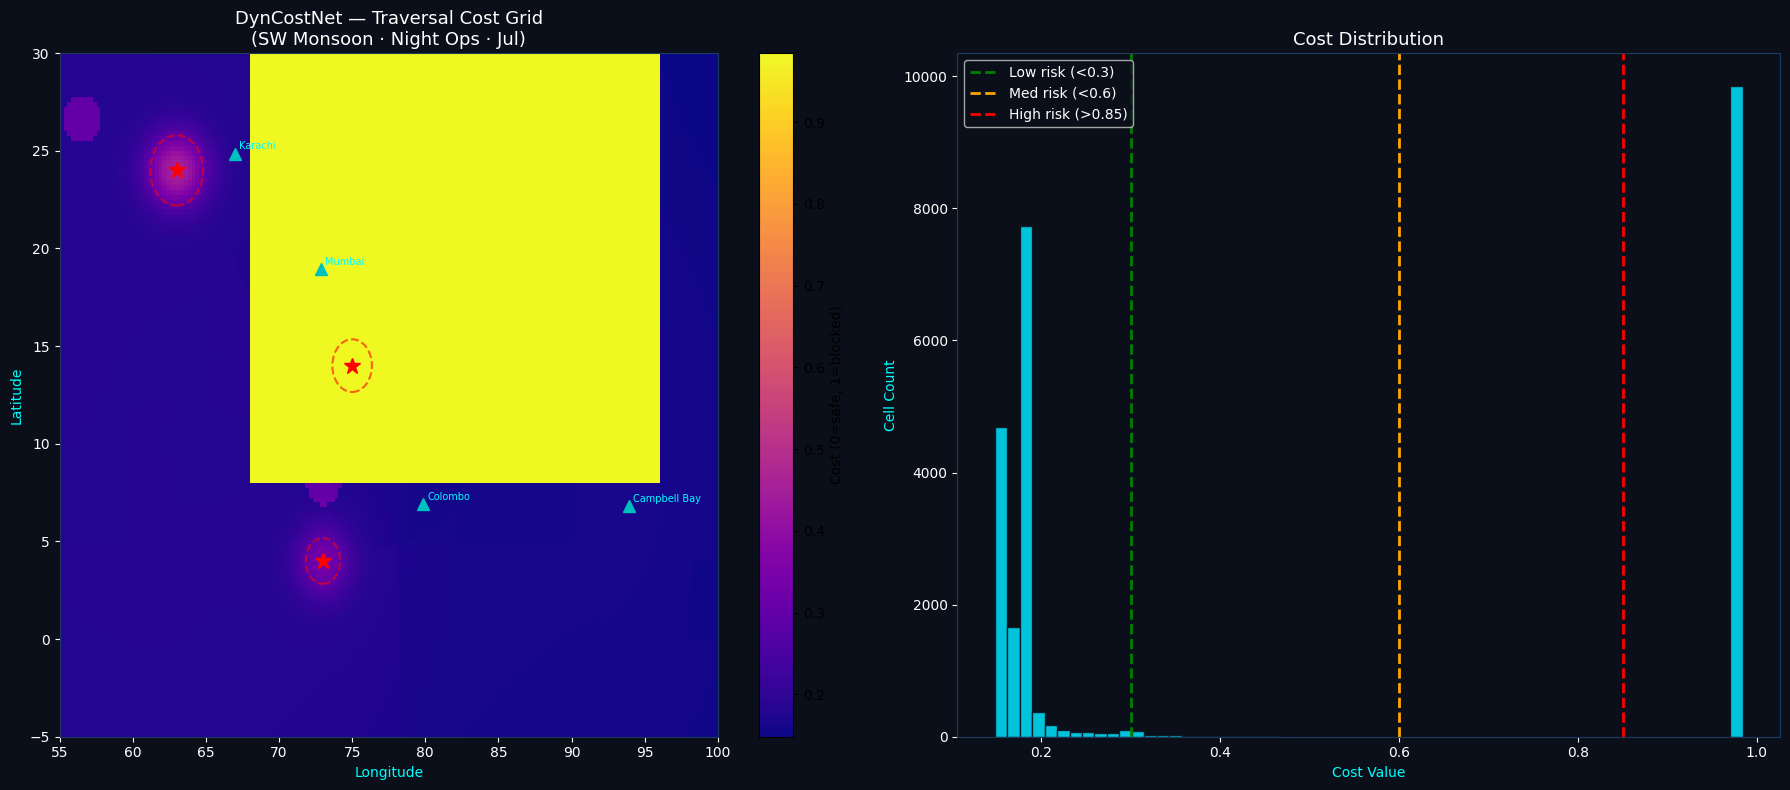

✅ Heatmap saved to cost_grid_viz.png


In [12]:
# ── Cell 9: Cost Grid Heatmap Visualization ──────────────────────────────────
# Visualize the 140×180 learned cost grid for SW Monsoon + Night scenario

import importlib, sys, os
# Force-reload config so new aliases are picked up
for mod_name in list(sys.modules):
    if mod_name.startswith("detection.path_planner"):
        importlib.reload(sys.modules[mod_name])

import numpy as np
import matplotlib.pyplot as plt
from detection.path_planner.cost_grid import build_cost_grid, cell_to_latlon, load_and_build_grid
from detection.path_planner.config import (
    GRID_ROWS, GRID_COLS, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, MODEL_PATH, N_FEATURES
)
from detection.path_planner.threat_model import load_model
from detection.path_planner.feature_builder import build_features_batch

# Threat zones for visualization
viz_threats = [
    {"lat": 24.0, "lon": 63.0, "radius": 200000, "threatLevel": 95},  # Pakistan Makran coast
    {"lat": 14.0, "lon": 75.0, "radius": 150000, "threatLevel": 75},  # Central AS
    {"lat": 4.0,  "lon": 73.0, "radius": 130000, "threatLevel": 65},  # Maldives area
]
weather = {
    "sea_state": 5,          # SW Monsoon heavy seas
    "wave_height": 4.0,
    "wind_speed": 22.0,
    "visibility": 6.0,
}
utc_hour = 23   # Night ops
month = 7       # July — peak monsoon

# Try to load trained model; fallback to expert cost if not available
print("Building 140×180 cost grid…")
if os.path.exists(MODEL_PATH):
    print(f"   Using trained model: {MODEL_PATH}")
    grid, _model = load_and_build_grid(viz_threats, weather, utc_hour, month)
else:
    print("   No trained model found — using expert cost fallback")
    # Build grid with expert_cost manually
    from detection.path_planner.data_generator import expert_cost
    from detection.path_planner.feature_builder import build_features
    lats = np.linspace(LAT_MIN, LAT_MAX, GRID_ROWS)
    lngs = np.linspace(LON_MIN, LON_MAX, GRID_COLS)
    grid = np.zeros((GRID_ROWS, GRID_COLS), dtype=np.float32)
    for i, lat in enumerate(lats):
        for j, lng in enumerate(lngs):
            feats = build_features(lat, lng, viz_threats, weather, utc_hour, month)
            grid[i, j] = expert_cost(feats, viz_threats, lat, lng)

print(f"Grid shape: {grid.shape}, range: [{grid.min():.3f}, {grid.max():.3f}]")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor("#0a0f1a")

for ax in axes:
    ax.set_facecolor("#0a0f1a")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e3a5f")

# Left: heatmap
im = axes[0].imshow(
    grid, origin="lower", cmap="plasma",
    extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto"
)
axes[0].set_title("DynCostNet — Traversal Cost Grid\n(SW Monsoon · Night Ops · Jul)", color="white", fontsize=13)
axes[0].set_xlabel("Longitude", color="cyan")
axes[0].set_ylabel("Latitude", color="cyan")
plt.colorbar(im, ax=axes[0], label="Cost (0=safe, 1=blocked)")

# Overlay threat zones
for z in viz_threats:
    axes[0].plot(z["lon"], z["lat"], "r*", markersize=12)
    circle = plt.Circle((z["lon"], z["lat"]),
                         z["radius"] / 111000,
                         color="red", fill=False, linestyle="--", lw=1.5, alpha=0.6)
    axes[0].add_patch(circle)

# Key points
for name, lat, lng in [("Mumbai", 18.94, 72.84), ("Campbell Bay", 6.83, 93.93),
                        ("Karachi", 24.86, 67.01), ("Colombo", 6.93, 79.84)]:
    axes[0].plot(lng, lat, "c^", markersize=8)
    axes[0].annotate(name, (lng, lat), color="cyan", fontsize=7,
                     xytext=(3, 3), textcoords="offset points")

# Right: cost histogram
axes[1].hist(grid.flatten(), bins=60, color="#00e5ff", edgecolor="#0a0f1a", alpha=0.85)
axes[1].set_title("Cost Distribution", color="white", fontsize=13)
axes[1].set_xlabel("Cost Value", color="cyan")
axes[1].set_ylabel("Cell Count", color="cyan")
axes[1].axvline(0.3, color="green",  lw=2, linestyle="--", label="Low risk (<0.3)")
axes[1].axvline(0.6, color="orange", lw=2, linestyle="--", label="Med risk (<0.6)")
axes[1].axvline(0.85, color="red",   lw=2, linestyle="--", label="High risk (>0.85)")
axes[1].legend(facecolor="#0a0f1a", labelcolor="white")

plt.tight_layout()
plt.savefig("cost_grid_viz.png", dpi=130, bbox_inches="tight", facecolor="#0a0f1a")
plt.show()
print("✅ Heatmap saved to cost_grid_viz.png")

# 📥 Step 10 — Download Trained Model & Deploy

After training completes above, run the cell below to download `dyn_cost_net.pt`.

Then copy it to your project:
```
detection/path_planner/dyn_cost_net.pt
```

Once placed there, the mission planner API at `/api/mission/plan-path` will automatically use the trained neural network instead of the expert-cost fallback.

---
**Deployment checklist:**
- [ ] `dyn_cost_net.pt` copied to `detection/path_planner/`
- [ ] Python dependencies installed: `pip install torch numpy scipy requests`
- [ ] Next.js API route live: `app/api/mission/plan-path/route.ts`
- [ ] Click **AI PLAN PATH** in the Mission Planner UI


In [ ]:
# ── Cell 10: Verify trained model ─────────────────────────────────────────────
import os

model_path = "detection/path_planner/dyn_cost_net.pt"

if os.path.exists(model_path):
    size_kb = os.path.getsize(model_path) / 1024
    print(f"✅ Model found: {model_path}")
    print(f"   Size: {size_kb:.1f} KB")
    print(f"\n🎯 Your model is already in place!")
    print(f"   The Mission Planner API (/api/mission/plan-path) will use it automatically.")
    print(f"   Just start your Next.js server:  npm run dev")
    print(f"   Then click 'AI PLAN PATH' in the Mission Planner UI.")
else:
    print("⚠️  Model not found. Run Cell 6 (training) first.")
    print(f"   Expected path: {model_path}")

✅ Model found: detection/path_planner/dyn_cost_net.pt
   Size: 497.0 KB

🎯 Your model is already in place!
   The Mission Planner API (/api/mission/plan-path) will use it automatically.
   Just start your Next.js server:  npm run dev
   Then click 'AI PLAN PATH' in the Mission Planner UI.


: 